# Day3: 머신러닝 이해와 실습

## 학습 내용
1. Decision tree
2. 랜덤포레스트
3. 교차검증

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets

In [4]:
# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (5,5)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 불러오기

In [20]:
# 데이터 불러오기
iris = datasets.load_iris()
print("iris dataset = \n", iris.keys())


iris dataset = 
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
# 1. 붓꽃(Iris) 데이터셋의 특성(feature) 데이터 로드
# 붓꽃의 꽃잎(petal) 길이/너비, 꽃받침(sepal) 길이/너비와 같은 수치형 특성 데이터가 저장됩니다.
data = iris.data

# 2. 붓꽃 데이터셋의 타겟(target) 데이터 로드
# 각 샘플(꽃)이 속하는 붓꽃 품종(setosa, versicolor, virginica)의 정수형 레이블(0, 1, 2)이 저장됩니다.
target = iris.target

print()
# 정수 레이블(0, 1, 2)이 어떤 품종을 의미하는지 확인합니다.
print("feature names = ", iris["feature_names"])
display("X = ", data[:10])

print()
# 분류 문제에서 예측해야 할 클래스의 종류(0, 1, 2)를 확인합니다.
print("iris target = \n", iris["target_names"])
print("y = ", np.unique(target))


feature names =  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


'X = '

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])


iris target = 
 ['setosa' 'versicolor' 'virginica']
y =  [0 1 2]


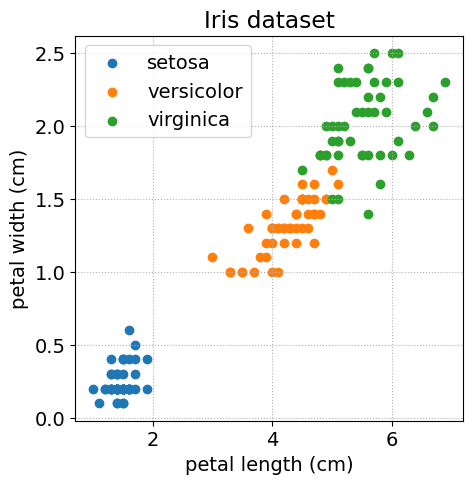

In [ ]:
# 1. 품종별 데이터 분리
setosa = data[target == 0]
versicolor = data[target == 1]
virginica = data[target ==2]

# --- 산점도(Scatter Plot) 그리기 ---
plt.scatter(setosa[:, 2], setosa[:, 3], label = "setosa")
plt.scatter(versicolor[:, 2], versicolor[:, 3], label = "versicolor")
plt.scatter(virginica[:, 2], virginica[:, 3], label = "virginica")
plt.title("Iris dataset")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")

plt.legend()
plt.show()

## 2. 의사결정나무 (Decision tree, DT)

In [ ]:
# Scikit-learn 라이브러리에서 DecisionTreeClassifier 클래스를 가져옵니다.
from sklearn.tree import DecisionTreeClassifier

# 1. 의사 결정 나무 모델 객체 생성
# max_depth=3: 트리의 최대 깊이를 3으로 제한하여 모델의 복잡도를 조절합니다.
#              (즉, 최대 3번의 질문(분할)만 허용하여 과적합을 방지하는 규제 역할)
# random_state=42: 결과를 항상 동일하게 재현하기 위해 난수 시드(seed)를 고정합니다.
tree_iris = DecisionTreeClassifier(max_depth=3, random_state=42) # max_depth를 주지 않으면 계속해서 나무가 뻗어나가는 문제 발생.

# 2. 모델 적합 (학습)
# tree_iris 모델에 훈련 데이터(data)와 그에 해당하는 정답(target)을 제공하여 학습시킵니다.
# 'data' (X): 붓꽃의 특성 데이터 (입력)
# 'target' (y): 붓꽃의 품종 레이블 (정답)
tree_iris.fit(data, target)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Feature Importances:
[0.    0.    0.586 0.414]

sepal length (cm): 0.000
sepal width (cm): 0.000
petal length (cm): 0.586
petal width (cm): 0.414


<Axes: >

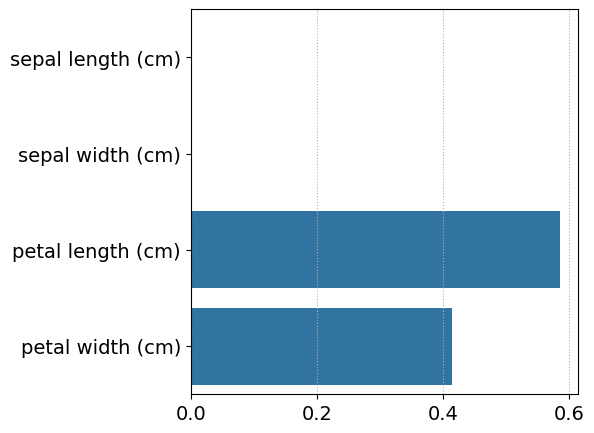

In [ ]:
# 1. 학습된 의사 결정 나무 모델(tree_iris)에서 각 특성의 중요도를 추출합니다.
# feature_importances_ 속성은 특성의 개수만큼의 배열을 반환하며, 
# 값의 총합은 1입니다. 값이 높을수록 분류에 중요한 특성입니다
print("Feature Importances:\n{0}\n".format(np.round(tree_iris.feature_importances_, 3)))


# 2. 붓꽃 데이터의 특성 이름(iris.feature_names)과 중요도 값(tree_iris.feature_importances_)을 묶어(zip) 순회합니다.
for name, value in zip(iris.feature_names, tree_iris.feature_importances_):
    print('{0}: {1:.3f}'.format(name, value))

# 3. Seaborn 라이브러리의 barplot을 사용하여 특성 중요도를 막대 그래프로 시각화합니다.
sns.barplot(x=tree_iris.feature_importances_, y=iris.feature_names)

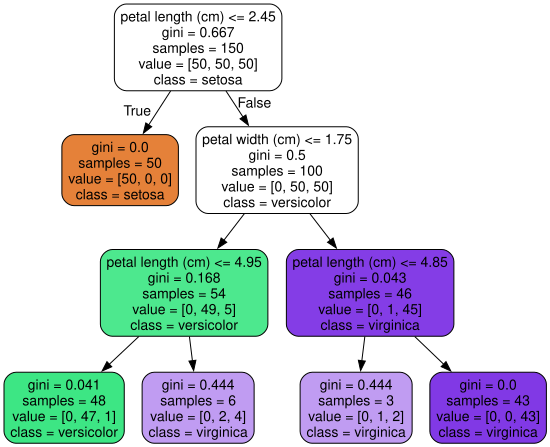

In [ ]:
# graphviz 라이브러리에서 Source 클래스를 가져옵니다. 
# 이는 .dot 파일을 읽어 그래프 객체로 변환하는 데 사용됩니다.

from graphviz import Source
from sklearn.tree import export_graphviz
export_graphviz(
        tree_iris,
        out_file=os.path.join(os.getcwd(), "iris_tree.dot"),
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )
# export_graphviz 함수를 호출하여 tree_iris 모델을 .dot 파일로 변환합니다.
Source.from_file(os.path.join(os.getcwd(), "iris_tree.dot"))

## 3. 랜덤포레스트 (RF) 와 교차검증 (CV)

In [ ]:
# Scikit-learn 라이브러리에서 데이터 분할을 위한 train_test_split 함수를 가져옵니다.
from sklearn.model_selection import train_test_split

# 최종 결과 변수:
# train_input: 모델을 학습시키는 데 사용될 훈련용 특성 데이터 (80%)
# test_input: 모델의 최종 성능을 평가하는 데 사용될 테스트용 특성 데이터 (20%)
# train_target: 훈련용 특성 데이터에 대응하는 정답 레이블
# test_target: 테스트용 특성 데이터에 대응하는 정답 레이블
train_input, test_input, train_target, test_target = train_test_split(data, target, 
                                                                      test_size=0.2, random_state=42)

In [ ]:
# Scikit-learn 라이브러리에서 RandomForestClassifier 클래스를 가져옵니다.
# 이 클래스는 여러 개의 결정 트리를 결합하여 분류를 수행하는 앙상블 모델입니다.
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100 trees: 포레스트에 포함될 결정 트리의 개수입니다.
# random_state: 샘플링(부트스트랩) 및 특성 샘플링의 무작위성을 제어하여 재현성을 보장합니다.   
rf = RandomForestClassifier(n_estimators=100, 
                            criterion='gini', 
                            max_depth = 3,   # 개별 트리의 최대 깊이를 3으로 제한합니다.                
                            random_state=42)
# RandomForestClassifier(
#     n_estimators=100, 포레스트 안에 생성할 결정 트리의 개수를 지정합니다.
#     *,
#     criterion='gini', 각 분할(split)의 품질을 측정하는 기준
#     max_depth=None, 개별 트리의 최대 깊이를 설정
#     min_samples_split=2, 노드를 분할하기 위해 필요한 최소 샘플 수
#     min_samples_leaf=1, 리프 노드(leaf node)가 되기 위해 필요한 최소 샘플 수
#     min_weight_fraction_leaf=0.0,
#     max_features='auto', 최적의 분할을 찾기 위해 고려할 특성(feature)의 최대 개수
#     max_leaf_nodes=None, 최대 leaf node
#     min_impurity_decrease=0.0,
#     min_impurity_split=None,
# )


In [25]:
# Scikit-learn에서 교차 검증을 위한 cross_validate 함수를 가져옵니다.
from sklearn.model_selection import cross_validate

# cross_validate 함수를 실행하여 모델의 성능을 측정합니다.
scores = cross_validate(rf, 
                        train_input, 
                        train_target, 
                        return_train_score=True, 
                        )

print("train_score = ", np.mean(scores['train_score']))
print("test_score = ", np.mean(scores['test_score']))

train_score =  0.9625
test_score =  0.95


In [ ]:
# 최종 모델 학습 (전체 훈련 데이터 사용)
rf.fit(train_input, train_target)

# 최종 테스트 데이터셋 (test_input, test_target)을 이용해 예측 수행
# 이 데이터셋은 훈련이나 교차 검증에 사용되지 않은 독립적인 데이터여야 합니다.
rf.score(test_input, test_target)

# 이전에 훈련된 랜덤 포레스트 분류기 모델 객체(rf)의 predict 메서드를 호출합니다.
# test_input: 모델을 훈련할 때 사용되지 않은 독립적인 테스트용 특성 데이터 (X)
# 이 함수는 test_input의 각 샘플에 대해 모델이 예측한 타겟 레이블(품종 ID: 0, 1, 2) 배열을 반환합니다.
rf.predict(test_input)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])